In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
sns.set()

In [2]:
df_train = pd.read_csv("../../data/dtec/dTEC_train.csv", index_col=0)
df_test = pd.read_csv("../../data/dtec/dTEC_test.csv", index_col=0)

In [3]:
df_train.head()

,Time,SatID,dTEC,Class,Event_name,StationID,dTEC-10,dTEC-9,dTEC-8,dTEC-7,dTEC-6,dTEC-5,dTEC-4,dTEC-3,dTEC-2,dTEC-1
0,3/11/2011 5:05,G15,-0.055487,0,Tohoku,J0041,-0.000381,0.003298,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487
1,3/11/2011 5:06,G15,0.028164,0,Tohoku,J0041,0.003298,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164
2,3/11/2011 5:06,G15,0.078863,0,Tohoku,J0041,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863
3,3/11/2011 5:07,G15,0.011011,0,Tohoku,J0041,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863,0.011011
4,3/11/2011 5:07,G15,-0.067521,0,Tohoku,J0041,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863,0.011011,-0.067521


In [4]:
df_test.head()

,Time,SatID,dTEC,Class,Event_name,StationID,dTEC-10,dTEC-9,dTEC-8,dTEC-7,dTEC-6,dTEC-5,dTEC-4,dTEC-3,dTEC-2,dTEC-1
0,1/15/2022 3:05,G10,-0.059215,0,Tonga,LAUT,0.074218,0.041935,0.009234,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215
1,1/15/2022 3:05,G10,-0.059376,0,Tonga,LAUT,0.041935,0.009234,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376
2,1/15/2022 3:06,G10,-0.061546,0,Tonga,LAUT,0.009234,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376,-0.061546
3,1/15/2022 3:06,G10,-0.069589,0,Tonga,LAUT,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376,-0.061546,-0.069589
4,1/15/2022 3:07,G10,-0.083846,0,Tonga,LAUT,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376,-0.061546,-0.069589,-0.083846


In [5]:
df_train[df_train['Event_name'] == 'Alaska_18']

,Time,SatID,dTEC,Class,Event_name,StationID,dTEC-10,dTEC-9,dTEC-8,dTEC-7,dTEC-6,dTEC-5,dTEC-4,dTEC-3,dTEC-2,dTEC-1
0,1/23/2018 9:17,G05,-0.024716,0,Alaska_18,AV06,-0.000306,-0.000296,-0.018545,-0.021405,0.004732,0.023314,0.018649,0.003173,-0.017687,-0.024716
1,1/23/2018 9:17,G05,-0.003521,0,Alaska_18,AV06,-0.000296,-0.018545,-0.021405,0.004732,0.023314,0.018649,0.003173,-0.017687,-0.024716,-0.003521
2,1/23/2018 9:18,G05,0.015844,0,Alaska_18,AV06,-0.018545,-0.021405,0.004732,0.023314,0.018649,0.003173,-0.017687,-0.024716,-0.003521,0.015844
3,1/23/2018 9:18,G05,0.011721,0,Alaska_18,AV06,-0.021405,0.004732,0.023314,0.018649,0.003173,-0.017687,-0.024716,-0.003521,0.015844,0.011721
4,1/23/2018 9:18,G05,-0.000781,0,Alaska_18,AV06,0.004732,0.023314,0.018649,0.003173,-0.017687,-0.024716,-0.003521,0.015844,0.011721,-0.000781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,1/23/2018 10:58,G05,0.011657,0,Alaska_18,AV26,0.005365,0.005276,-0.001061,-0.009208,-0.011320,-0.006201,-0.000894,0.001014,0.004522,0.011657
406,1/23/2018 10:59,G05,0.014832,0,Alaska_18,AV26,0.005276,-0.001061,-0.009208,-0.011320,-0.006201,-0.000894,0.001014,0.004522,0.011657,0.014832
407,1/23/2018 10:59,G05,0.009327,0,Alaska_18,AV26,-0.001061,-0.009208,-0.011320,-0.006201,-0.000894,0.001014,0.004522,0.011657,0.014832,0.009327
408,1/23/2018 10:59,G05,0.002175,0,Alaska_18,AV26,-0.009208,-0.011320,-0.006201,-0.000894,0.001014,0.004522,0.011657,0.014832,0.009327,0.002175


In [48]:
alaska = df_train[df_train['Event_name'] == 'Alaska_18']
alaska['Time'] = pd.to_datetime(alaska['Time'])
drop_cols = []
for i in range(1, 11):
    drop_cols.append('dTEC-'+str(i))
alaska = alaska.drop(drop_cols, axis=1)
alaska = alaska.drop(['SatID', 'Event_name'], axis=1)
alaska.head()

/tmp/ipykernel_4427/1054522899.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alaska['Time'] = pd.to_datetime(alaska['Time'])


,Time,dTEC,Class,StationID
0,2018-01-23 09:17:00,-0.024716,0,AV06
1,2018-01-23 09:17:00,-0.003521,0,AV06
2,2018-01-23 09:18:00,0.015844,0,AV06
3,2018-01-23 09:18:00,0.011721,0,AV06
4,2018-01-23 09:18:00,-0.000781,0,AV06


In [49]:
alaska_piv = alaska.pivot(columns='StationID', values='dTEC')
alaska_piv.tail()

StationID,AV06,AV07,AV09,AV10,AV26
405,-0.000778,NaN,NaN,NaN,0.011657
406,0.005440,NaN,NaN,NaN,0.014832
407,-0.000231,NaN,NaN,NaN,0.009327
408,-0.007714,NaN,NaN,NaN,0.002175
409,-0.000073,NaN,NaN,NaN,-0.000158


In [50]:
alaska_time_piv = alaska.pivot(columns='StationID', values='Time')
alaska_time_piv

StationID,AV06,AV07,AV09,AV10,AV26
0,2018-01-23 09:17:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:17:00
1,2018-01-23 09:17:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:17:00
2,2018-01-23 09:18:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:18:00
3,2018-01-23 09:18:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:18:00
4,2018-01-23 09:18:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:18:00
...,...,...,...,...,...
405,2018-01-23 10:58:00,NaT,NaT,NaT,2018-01-23 10:58:00
406,2018-01-23 10:59:00,NaT,NaT,NaT,2018-01-23 10:59:00
407,2018-01-23 10:59:00,NaT,NaT,NaT,2018-01-23 10:59:00
408,2018-01-23 10:59:00,NaT,NaT,NaT,2018-01-23 10:59:00


In [51]:
alaska_class_piv = alaska.pivot(columns='StationID', values='Class')
#alaska_class_piv = alaska_class_piv.iloc[0:390, :]
last_idx = 390
length = alaska_class_piv.shape[0]
shift_stations = ['AV07', 'AV09', 'AV10']
for stat in shift_stations:
    alaska_piv.loc[:, stat] = alaska_piv.loc[:, stat].shift(length-last_idx)
    alaska_class_piv.loc[:, stat] = alaska_class_piv.loc[:, stat].shift(length-last_idx)
    alaska_time_piv.loc[:, stat] = alaska_time_piv.loc[:, stat].shift(length-last_idx)
alaska_piv = alaska_piv.iloc[length-last_idx:, :]
alaska_class_piv = alaska_class_piv.iloc[length-last_idx:, :]
alaska_time_piv = alaska_time_piv.iloc[length-last_idx:, :]
alaska_class_piv.tail()

StationID,AV06,AV07,AV09,AV10,AV26
405,0.0,0.0,0.0,0.0,0.0
406,0.0,0.0,0.0,0.0,0.0
407,0.0,0.0,0.0,0.0,0.0
408,0.0,0.0,0.0,0.0,0.0
409,0.0,0.0,0.0,0.0,0.0


In [52]:
alaska_class_piv.head()

StationID,AV06,AV07,AV09,AV10,AV26
20,0.0,0.0,0.0,0.0,0.0
21,0.0,0.0,0.0,0.0,0.0
22,0.0,0.0,0.0,0.0,0.0
23,0.0,0.0,0.0,0.0,0.0
24,0.0,0.0,0.0,0.0,0.0


In [53]:
alaska_class_piv.isnull().any()

StationID
AV06    False
AV07    False
AV09    False
AV10    False
AV26    False
dtype: bool

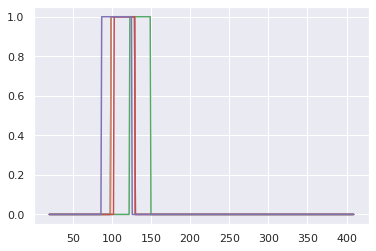

In [54]:
plt.plot(alaska_class_piv)

In [55]:
alaska_time_piv.tail()

StationID,AV06,AV07,AV09,AV10,AV26
405,2018-01-23 10:58:00,2018-01-23 10:58:00,2018-01-23 10:58:00,2018-01-23 10:58:00,2018-01-23 10:58:00
406,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00
407,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00
408,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00
409,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00


In [56]:
alaska_time_piv.head()

StationID,AV06,AV07,AV09,AV10,AV26
20,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00
21,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00
22,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00
23,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00
24,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00


In [57]:
alaska_piv.tail()

StationID,AV06,AV07,AV09,AV10,AV26
405,-0.000778,-0.002612,-0.012221,0.007458,0.011657
406,0.005440,-0.007039,-0.012882,0.010342,0.014832
407,-0.000231,-0.007840,0.013121,-0.023235,0.009327
408,-0.007714,-0.007433,0.025371,-0.055322,0.002175
409,-0.000073,0.000613,-0.000490,0.000723,-0.000158


In [58]:
alaska_piv.head()

StationID,AV06,AV07,AV09,AV10,AV26
20,0.004930,-0.015874,-0.032466,-0.009529,0.008428
21,0.011791,-0.003493,-0.024800,-0.021190,0.006509
22,0.005906,0.018676,-0.027544,-0.003311,-0.005410
23,0.001682,0.020276,-0.029461,-0.005799,-0.022686
24,0.004521,0.002334,0.001592,-0.017962,-0.026039


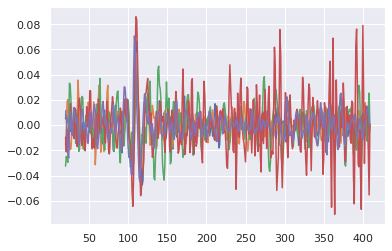

In [60]:
plt.plot(alaska_piv)

In [61]:
scaler = StandardScaler()
alaska_vals = scaler.fit_transform(alaska_piv.values)

In [62]:
print(alaska_vals.shape)

(390, 5)


In [63]:
np.savetxt('../../data/dtec/alaska.csv', alaska_vals, delimiter=",")

In [64]:
np.linalg.det(np.cov(alaska_vals.T))

0.5577808096452395

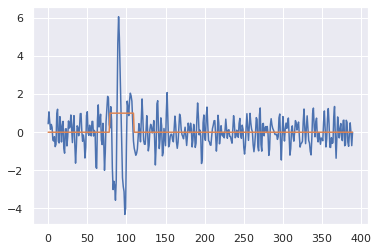

In [66]:
plt.plot(alaska_vals[:, 0])
plt.plot(alaska_class_piv.values[:, 0])

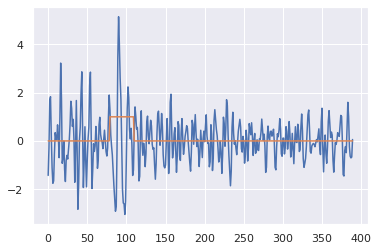

In [67]:
plt.plot(alaska_vals[:, 1])
plt.plot(alaska_class_piv.values[:, 1])

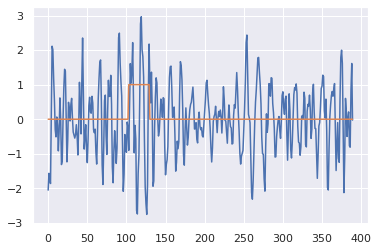

In [68]:
plt.plot(alaska_vals[:, 2])
plt.plot(alaska_class_piv.values[:, 2])

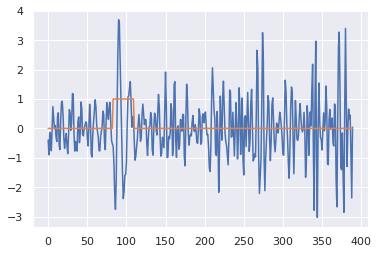

In [69]:
plt.plot(alaska_vals[:, 3])
plt.plot(alaska_class_piv.values[:, 3])

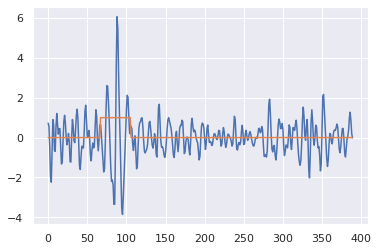

In [70]:
plt.plot(alaska_vals[:, 4])
plt.plot(alaska_class_piv.values[:, 4])